R evolution equation correlations — Figure 4

This notebook does:

1. Load a DNS vorticity field `w(t,x,y)` from a NetCDF file (variable name: `w`).
2. Compute the LCR decomposition and compute the local correlations to tau, the flux correlations to tau and the ratio of the total fluxes to tau
3. Plot and save the data

In [1]:
# ----------------------------
# Imports & configuration
# ----------------------------
from __future__ import annotations

from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import jax_cfd.base as cfd
import jax_cfd.base.grids as grids
import jax_cfd.spectral as spectral

jax.config.update("jax_enable_x64", True)

In [2]:
# ----------------------------
# User knobs
# ----------------------------
# Note: You want to create a dataset at higher resolution and lower viscosity. 
# This is an example for 2048^2 data at nu = 1e-6. 
INP = Path("/storage/home/hcoda1/4/mugliotti3/scratch/temporary/DNS.nc")

# Output: Where to save
OUT_DIR = Path("/storage/home/hcoda1/4/mugliotti3/scratch/temporary/")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PATH = OUT_DIR / "LCR_metrics_vs_delta.txt"

# ----------------------------
# Some imports that are needed
# ----------------------------
ds = xr.open_dataset(INP)
if "w" not in ds:
    raise KeyError(f"Expected variable 'w' in {INP}, found: {list(ds.data_vars)}")
    
nu = float(ds.attrs["nu"])  
w0 = jnp.asarray(ds["w"].values)
if w0.ndim != 3:
    raise ValueError(f"Expected 2D vorticity field, got shape {w0.shape}")
Nt, Nx, Ny = w0.shape
w_hat_traj = jnp.fft.rfft2(w0, axes=(1,2))
print(f"Loaded w0 with shape (Nt, Nx, Ny) = {w0.shape}")
dt = float(ds.attrs["save_every"])  

Lengthscale = (2*jnp.pi/28)                 #Set you lengthscale here of you file
Delta_min = 0.01*Lengthscale                #Set minimum Delta you want
Delta_max = 1* Lengthscale                  #Set maximum Delta you want
Delta_amount = 20                           #How many Deltas in total to compute over

Loaded w0 with shape (Nt, Nx, Ny) = (10, 2048, 2048)


In [3]:
# ----------------------------
# Some functions we need
# ----------------------------

from jax import vmap
def fourier_filter(field, Delta):

    if field.ndim not in (2, 3, 4):
        raise ValueError("field must have 2D, 3D, or 4D shape")

    Nx, Ny = field.shape[:2]

    qx = jnp.fft.fftfreq(Nx) * Nx
    qy = jnp.fft.fftfreq(Ny) * Ny
    X, Y = jnp.meshgrid(qy, qx)
    R2 = X**2 + Y**2
    G = jnp.exp(-R2 * (Delta**2) / 24.0).astype(field.dtype)

    def filt2(x2d):
        F = jnp.fft.fft2(x2d, axes=(-2, -1))
        Y = F * G
        y = jnp.fft.ifft2(Y, axes=(-2, -1))
        return y.real.astype(field.dtype) if jnp.isrealobj(field) else y.astype(field.dtype)

    if field.ndim == 2:
        return filt2(field)

    elif field.ndim == 3:  # (Nx,Ny,C)
        return vmap(filt2, in_axes=2, out_axes=2)(field)

    else:  # (Nx,Ny,C,T)
        def filt3(x3d):  # x3d = (Nx,Ny,C)
            return vmap(filt2, in_axes=2, out_axes=2)(x3d)
        return vmap(filt3, in_axes=3, out_axes=3)(field)

def C_maxnorm_3D(A: np.ndarray, B: np.ndarray) -> np.number:
    AB = np.sum(A * B, axis=(-2, -1))
    AA = np.sum(A * A, axis=(-2, -1))
    BB = np.sum(B * B, axis=(-2, -1))
    num    = np.sum(AB)
    AA_sum = np.sum(AA)
    BB_sum = np.sum(BB)
    den = np.maximum(AA_sum, BB_sum)
    return num / den

def compute_flux(S: np.ndarray, T: np.ndarray) -> np.number:
    ST = -np.sum(S * T, axis=(-2, -1))     
    return ST

In [4]:
# ----------------------------
# Convert omega to U,V
# ----------------------------
Nt, Nx, Ny = w0.shape   # w0 = (time, x, y)

grid = grids.Grid((Nx, Ny), domain=((0.0, 2*jnp.pi), (0.0, 2*jnp.pi)))
w_to_v_dns = spectral.utils.vorticity_to_velocity(grid)

# FFT per snapshot
w_hat = jnp.fft.rfft2(jnp.asarray(w0, dtype=jnp.float64), axes=(1, 2))
# shape: (Nt, Nx, Ny//2+1)

# ---- vectorize the operator over time ----
u_hat, v_hat = jax.vmap(w_to_v_dns)(w_hat)
# shapes: (Nt, Nx, Ny//2+1)

U = jnp.fft.irfft2(u_hat, axes=(1, 2))
V = jnp.fft.irfft2(v_hat, axes=(1, 2))
# shapes: (Nt, Nx, Ny)

# ---- transpose to what your ratios code expects ----
U = jnp.transpose(U, (1, 2, 0))   # (Nx, Ny, Nt)
V = jnp.transpose(V, (1, 2, 0))

u = jnp.stack((U, V), axis=-1) 

In [5]:
# ----------------------------
# Some more functions
# ----------------------------
def ngm_from_u_jnp(u_bar: jnp.ndarray, Delta: float):
    """
    u_bar: (Nx, Ny, Nt, 2) filtered velocity
    returns: L(=NGM2), C(=NGM4), S (all shape (Nx,Ny,Nt,2,2))
    """
    Nx, Ny, Nt, _ = u_bar.shape
    dx = 2*jnp.pi / Nx
    dy = 2*jnp.pi / Ny

    # angular wavenumbers (integers on 2π box)
    kx = jnp.fft.fftfreq(Nx, d=dx) * 2*jnp.pi
    ky = jnp.fft.fftfreq(Ny, d=dy) * 2*jnp.pi
    KX, KY = jnp.meshgrid(kx, ky, indexing='ij')  # (Nx,Ny)
    IKX = (1j * KX)[..., None]                    # (Nx,Ny,1)
    IKY = (1j * KY)[..., None]

    # FFT on spatial axes only
    uhat = jnp.fft.fftn(u_bar[..., 0], axes=(0, 1))   # (Nx,Ny,Nt)
    vhat = jnp.fft.fftn(u_bar[..., 1], axes=(0, 1))

    # first derivatives
    du_dx = jnp.fft.ifftn(IKX * uhat, axes=(0, 1)).real
    du_dy = jnp.fft.ifftn(IKY * uhat, axes=(0, 1)).real
    dv_dx = jnp.fft.ifftn(IKX * vhat, axes=(0, 1)).real
    dv_dy = jnp.fft.ifftn(IKY * vhat, axes=(0, 1)).real

    # second derivatives (∂_{xx}u etc.; (i k)^2 = -k^2 gives correct sign)
    d2u_dx2  = jnp.fft.ifftn((IKX**2)     * uhat, axes=(0, 1)).real
    d2u_dy2  = jnp.fft.ifftn((IKY**2)     * uhat, axes=(0, 1)).real
    d2u_dxdy = jnp.fft.ifftn((IKX*IKY)    * uhat, axes=(0, 1)).real
    d2v_dx2  = jnp.fft.ifftn((IKX**2)     * vhat, axes=(0, 1)).real
    d2v_dy2  = jnp.fft.ifftn((IKY**2)     * vhat, axes=(0, 1)).real
    d2v_dxdy = jnp.fft.ifftn((IKX*IKY)    * vhat, axes=(0, 1)).real

    L_xx = du_dx**2 + du_dy**2
    L_yy = dv_dx**2 + dv_dy**2
    L_xy = du_dx*dv_dx + du_dy*dv_dy
    L = (Delta**2/12.0) * jnp.stack(
        [jnp.stack([L_xx, L_xy], axis=-1),
         jnp.stack([L_xy, L_yy], axis=-1)], axis=-2)

    C_xx = d2u_dx2**2 + d2u_dy2**2 + 2.0*(d2u_dxdy**2)
    C_yy = d2v_dx2**2 + d2v_dy2**2 + 2.0*(d2v_dxdy**2)
    C_xy = d2u_dx2*d2v_dx2 + d2u_dy2*d2v_dy2 + 2.0*(d2u_dxdy*d2v_dxdy)
    C = (Delta**4/288.0) * jnp.stack(
        [jnp.stack([C_xx, C_xy], axis=-1),
         jnp.stack([C_xy, C_yy], axis=-1)], axis=-2)

    # symmetric rate-of-strain from filtered velocity: S_ij = (∂_i u_j + ∂_j u_i)/2
    # build grad u (j index = velocity component)
    grad_u = jnp.stack(
        [jnp.stack([du_dx, du_dy], axis=-1),   # i = x row
         jnp.stack([dv_dx, dv_dy], axis=-1)],  # i = y row
        axis=-2)                                # (...,2,2) with indices (i,j)

    S = 0.5 * (grad_u + jnp.swapaxes(grad_u, -2, -1))

    return L, C, S

# ---------- jnp helpers ----------
def compute_flux_jnp(T: jnp.ndarray, S: jnp.ndarray) -> jnp.ndarray:
    # double contraction over the last two indices
    return jnp.sum(T * S, axis=(-2, -1))

def C_maxnorm_3D_jnp(A: jnp.ndarray, B: jnp.ndarray) -> jnp.ndarray:
    AB = jnp.sum(A * B, axis=(-2, -1))
    AA = jnp.sum(A * A, axis=(-2, -1))
    BB = jnp.sum(B * B, axis=(-2, -1))
    num = jnp.sum(AB)
    den = jnp.maximum(jnp.sum(AA), jnp.sum(BB))
    return num / den

def corr_scalar(a, b):
    num = jnp.sum(a * b)
    den = jnp.maximum(jnp.sum(a * a), jnp.sum(b * b))
    return num / den

In [6]:
# ----------------------------
# storage
# ----------------------------
L_corrs = []
C_corrs = []
R_corrs = []
LCR_corrs = []

L_flux_corrs = []
C_flux_corrs = []
R_flux_corrs = []
LCR_flux_corrs = []

L_flux_ratios = []
C_flux_ratios = []
R_flux_ratios = []
LCR_flux_ratios = []

# ----------------------------
# main loop
# ----------------------------
from tqdm import tqdm
Deltas = np.linspace(Delta_min, Delta_max, Delta_amount)
for Delta in tqdm(Deltas):
    u_bar = jnp.asarray(fourier_filter(u, float(Delta)))

    # SGS stress: tau_ij = overline(u_i u_j) - ubar_i ubar_j
    uu_xx = jnp.asarray(fourier_filter(u[..., 0] * u[..., 0], float(Delta)))
    uu_xy = jnp.asarray(fourier_filter(u[..., 0] * u[..., 1], float(Delta)))
    uu_yy = jnp.asarray(fourier_filter(u[..., 1] * u[..., 1], float(Delta)))
    tau = jnp.stack(
        [
            jnp.stack([uu_xx - u_bar[..., 0] ** 2, uu_xy - u_bar[..., 0] * u_bar[..., 1]], axis=-1),
            jnp.stack([uu_xy - u_bar[..., 0] * u_bar[..., 1], uu_yy - u_bar[..., 1] ** 2], axis=-1),
        ],
        axis=-2,
    )

    # NGM2/NGM4 + strain
    _, _, S = ngm_from_u_jnp(u_bar, float(Delta))

# --- L,C,R ---
    u_dash = u - u_bar
    u_bar_bar = jnp.asarray(fourier_filter(u_bar, Delta))
    
    ubarubar_xx = jnp.asarray(fourier_filter(u_bar[..., 0]*u_bar[..., 0], Delta))
    ubarubar_xy = jnp.asarray(fourier_filter(u_bar[..., 0]*u_bar[..., 1], Delta))
    ubarubar_yy = jnp.asarray(fourier_filter(u_bar[..., 1]*u_bar[..., 1], Delta))

    L = jnp.stack(
        [jnp.stack([ubarubar_xx - u_bar_bar[..., 0]**2,
                    ubarubar_xy - u_bar_bar[..., 0]*u_bar_bar[..., 1]], axis=-1),
         jnp.stack([ubarubar_xy - u_bar_bar[..., 0]*u_bar_bar[..., 1],
                    ubarubar_yy - u_bar_bar[..., 1]**2], axis=-1)],
        axis=-2
    )

    u_dash_bar = jnp.asarray(fourier_filter(u_dash, Delta))

    cross_xx = jnp.asarray(fourier_filter(2.0*u_bar[..., 0]*u_dash[..., 0], Delta))
    cross_xy = jnp.asarray(fourier_filter(u_bar[..., 0]*u_dash[..., 1] +
                                          u_dash[..., 0]*u_bar[..., 1], Delta))
    cross_yy = jnp.asarray(fourier_filter(2.0*u_bar[..., 1]*u_dash[..., 1], Delta))

    C = jnp.stack(
        [jnp.stack([cross_xx - 2.0*u_bar_bar[..., 0]*u_dash_bar[..., 0],
                    cross_xy - (u_bar_bar[..., 0]*u_dash_bar[..., 1] +
                                u_dash_bar[..., 0]*u_bar_bar[..., 1])], axis=-1),
         jnp.stack([cross_xy - (u_bar_bar[..., 0]*u_dash_bar[..., 1] +
                                u_dash_bar[..., 0]*u_bar_bar[..., 1]),
                    cross_yy - 2.0*u_bar_bar[..., 1]*u_dash_bar[..., 1]], axis=-1)],
        axis=-2
    )

    udud_xx = jnp.asarray(fourier_filter(u_dash[..., 0]*u_dash[..., 0], Delta))
    udud_xy = jnp.asarray(fourier_filter(u_dash[..., 0]*u_dash[..., 1], Delta))
    udud_yy = jnp.asarray(fourier_filter(u_dash[..., 1]*u_dash[..., 1], Delta))

    R = jnp.stack(
        [jnp.stack([udud_xx - u_dash_bar[..., 0]**2,
                    udud_xy - u_dash_bar[..., 0]*u_dash_bar[..., 1]], axis=-1),
         jnp.stack([udud_xy - u_dash_bar[..., 0]*u_dash_bar[..., 1],
                    udud_yy - u_dash_bar[..., 1]**2], axis=-1)],
        axis=-2
    )

    # tensor correlations
    L_corr = C_maxnorm_3D_jnp(tau, L)
    C_corr = C_maxnorm_3D_jnp(tau, C)
    R_corr = C_maxnorm_3D_jnp(tau, R)
    LCR_corr = C_maxnorm_3D_jnp(tau, L+C+R)

    L_corrs.append(float(L_corr))
    C_corrs.append(float(C_corr))
    R_corrs.append(float(R_corr))
    LCR_corrs.append(float(LCR_corr))

    # fluxes
    tau_flux = compute_flux_jnp(tau, S)
    L_flux   = compute_flux_jnp(L, S)
    C_flux  = compute_flux_jnp(C, S)
    R_flux = compute_flux_jnp(R, S)
    LCR_flux = compute_flux_jnp(L+C+R, S)

    # flux correlations (scalars)
    L_flux_local = corr_scalar(tau_flux, L_flux)
    C_flux_local = corr_scalar(tau_flux, C_flux)
    R_flux_local = corr_scalar(tau_flux, R_flux)
    LCR_flux_local = corr_scalar(tau_flux, LCR_flux)

    L_flux_corrs.append(float(L_flux_local))
    C_flux_corrs.append(float(C_flux_local))
    R_flux_corrs.append(float(R_flux_local))
    LCR_flux_corrs.append(float(LCR_flux_local))

    # flux sums / ratios
    L_flux_sum   = jnp.sum(L_flux)
    C_flux_sum   = jnp.sum(C_flux)
    R_flux_sum   = jnp.sum(R_flux)
    LCR_flux_sum = jnp.sum(LCR_flux)
    tau_flux_sum = jnp.sum(tau_flux)

    # safe ratio
    denom = float(tau_flux_sum) if abs(float(tau_flux_sum)) > 1e-30 else 1e-30
    L_flux_ratios.append(float(L_flux_sum) / denom)
    C_flux_ratios.append(float(C_flux_sum) / denom)
    R_flux_ratios.append(float(R_flux_sum) / denom)
    LCR_flux_ratios.append(float(LCR_flux_sum) / denom)

delta_norm = Deltas / Lengthscale
order = np.argsort(delta_norm)
delta_norm = delta_norm[order]

L_corrs = np.asarray(L_corrs)[order]
C_corrs = np.asarray(C_corrs)[order]
R_corrs = np.asarray(R_corrs)[order]
LCR_corrs = np.asarray(LCR_corrs)[order]

L_flux_corrs = np.asarray(L_flux_corrs)[order]
C_flux_corrs = np.asarray(C_flux_corrs)[order]
R_flux_corrs = np.asarray(R_flux_corrs)[order]
LCR_flux_corrs = np.asarray(LCR_flux_corrs)[order]

L_flux_ratios = np.asarray(L_flux_ratios)[order]
C_flux_ratios = np.asarray(C_flux_ratios)[order]
R_flux_ratios = np.asarray(R_flux_ratios)[order]
LCR_flux_ratios = np.asarray(LCR_flux_ratios)[order]

100%|██████████| 20/20 [00:06<00:00,  3.27it/s]


Saved: /storage/home/hcoda1/4/mugliotti3/scratch/temporary/LCR_metrics_vs_delta.txt


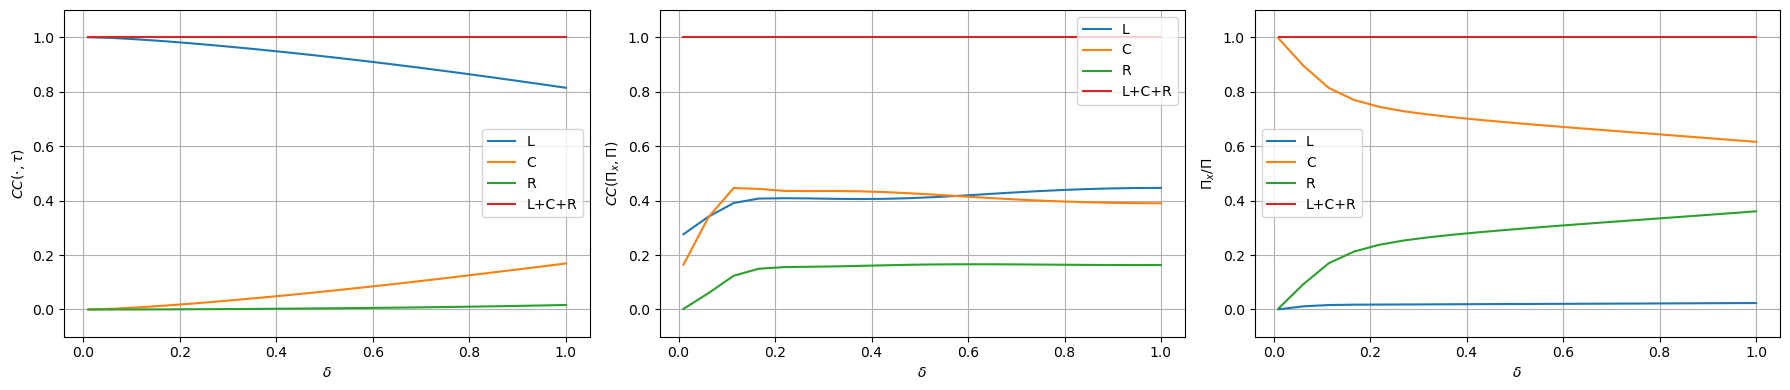

In [7]:
# ----------------------------
# SAVE (columns) to a txt file
# ----------------------------

header = (
    "delta_norm  Delta  "
    "L_corr  C_corr  R_corr LCR_corr"
    "L_flux_corr  C_flux_corr  R_flux_corr  LCR_flux_corr"
    "L_flux_ratio  C_flux_ratio  R_flux_ratio LCR_flux_ratio"
)

table = np.column_stack([
    delta_norm,
    Deltas[order],
    L_corrs, C_corrs, R_corrs,LCR_corrs,
    L_flux_corrs, C_flux_corrs, R_flux_corrs,LCR_flux_corrs,
    L_flux_ratios, C_flux_ratios, R_flux_ratios,LCR_flux_ratios
])

np.savetxt(OUT_PATH, table, header=header, fmt="%.10e")
print(f"Saved: {OUT_PATH}")

# ----------------------------
# Plot like paper
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# (1) tensor correlations
axes[0].plot(delta_norm, L_corrs, label="L")
axes[0].plot(delta_norm, C_corrs, label="C")
axes[0].plot(delta_norm, R_corrs, label="R")
axes[0].plot(delta_norm, LCR_corrs, label="L+C+R")
axes[0].legend()
axes[0].set_xlabel(r'$\delta$')
axes[0].set_ylabel(r'$CC(\cdot,\tau)$')
axes[0].set_ylim(-0.1, 1.1)
axes[0].grid(True)

# (2) flux correlations
axes[1].plot(delta_norm, L_flux_corrs, label="L")
axes[1].plot(delta_norm, C_flux_corrs, label="C")
axes[1].plot(delta_norm, R_flux_corrs, label="R")
axes[1].plot(delta_norm, LCR_flux_corrs, label="L+C+R")
axes[1].legend()
axes[1].set_xlabel(r'$\delta$')
axes[1].set_ylabel(r'$CC(\Pi_x,\Pi)$')
axes[1].set_ylim(-0.1, 1.1)
axes[1].grid(True)

# (3) flux ratios
axes[2].plot(delta_norm, L_flux_ratios, label="L")
axes[2].plot(delta_norm, C_flux_ratios, label="C")
axes[2].plot(delta_norm, R_flux_ratios, label="R")
axes[2].plot(delta_norm, LCR_flux_ratios, label="L+C+R")
axes[2].legend()
axes[2].set_xlabel(r'$\delta$')
axes[2].set_ylabel(r'$\Pi_x/\Pi$')
axes[2].set_ylim(-0.1, 1.1)
axes[2].grid(True)

plt.tight_layout()
plt.show()